# Image Processing Transforms Demonstration

This notebook demonstrates the difference between test (validation) transforms and training transforms on images from our dataset. We'll visualize how data augmentation affects the images during the training process versus the standard test preprocessing.

In [15]:
# Import required libraries
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import random
from PIL import Image

# Add project root to path to access modules
notebook_dir = os.getcwd()
project_root_path = os.path.dirname(notebook_dir)
sys.path.insert(0, project_root_path)

# Import our custom image processing functions
from src.config import PROJECT_ROOT
from src.preprocessing.image_processing import _get_transform_pipeline, _get_all_filenames

## 1. Setup - Select a Random Image

First, we'll define a function to select a random image from our dataset. We'll then apply both test and training transforms to it.

In [16]:
def get_random_image(image_dir):
    """
    Selects a random image from the dataset directory

    Args:
        image_dir (str): Directory containing images

    Returns:
        PIL Image: A randomly selected image
        str: Path to the selected image
    """
    all_image_paths = _get_all_filenames(image_dir)
    if not all_image_paths:
        raise ValueError(f"No images found in {image_dir}")

    # Select a random image
    random_image_path = random.choice(all_image_paths)
    img = Image.open(random_image_path).convert('RGB')

    return img, random_image_path

# Set the path to your images directory - adjust as needed
image_dir = os.path.join(PROJECT_ROOT, 'images', 'CUB')

# Check if the directory exists
if not os.path.exists(image_dir):
    print(f"Directory {image_dir} not found. Listing available directories:")
    print(os.listdir("../images"))

## 2. Helper Functions for Visualization

Let's define some helper functions to visualize the original image and its transformed versions.

In [17]:
def tensor_to_image(tensor):
    """
    Convert a tensor to a numpy array suitable for plotting

    Args:
        tensor (torch.Tensor): Image tensor with shape [C, H, W]

    Returns:
        numpy.ndarray: Image array with shape [H, W, C]
    """
    # Clone the tensor to avoid modifying the original
    img = tensor.clone().detach()

    # Convert to numpy and transpose from [C, H, W] to [H, W, C]
    img = img.numpy().transpose(1, 2, 0)

    # Denormalize
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([2.0, 2.0, 2.0])  # Using the values from _get_transform_pipeline

    img = std * img + mean

    # Clip values to [0, 1]
    img = np.clip(img, 0, 1)

    return img

def show_image_comparison(original_img, test_img, train_imgs, num_train_examples=5):
    """
    Display original image alongside its test transform and multiple training transforms

    Args:
        original_img (PIL.Image): Original PIL image
        test_img (torch.Tensor): Test transformed image tensor
        train_imgs (list): List of training transformed image tensors
        num_train_examples (int): Number of training examples to display
    """
    # Number of images to show (1 original + 1 test + n training)
    n_images = 2 + min(len(train_imgs), num_train_examples)

    fig, axes = plt.subplots(1, n_images, figsize=(20, 4))

    # Show original image
    axes[0].imshow(np.array(original_img))
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Show test transformed image
    test_np = tensor_to_image(test_img)
    axes[1].imshow(test_np)
    axes[1].set_title('Test Transform')
    axes[1].axis('off')

    # Show training transformed images
    for i in range(min(len(train_imgs), num_train_examples)):
        train_np = tensor_to_image(train_imgs[i])
        axes[i+2].imshow(train_np)
        axes[i+2].set_title(f'Training Transform {i+1}')
        axes[i+2].axis('off')

    plt.tight_layout()
    plt.show()

## 3. Apply Transforms and Visualize

Now we'll select a random image and apply both test and training transforms to it. We'll apply the training transforms multiple times to show the random augmentations.

## 3. Batch Visualization

Now let's visualize the difference across multiple random images to better understand the impact of transforms.


Image 1: Yellow_Throated_Vireo_0041_794998.jpg


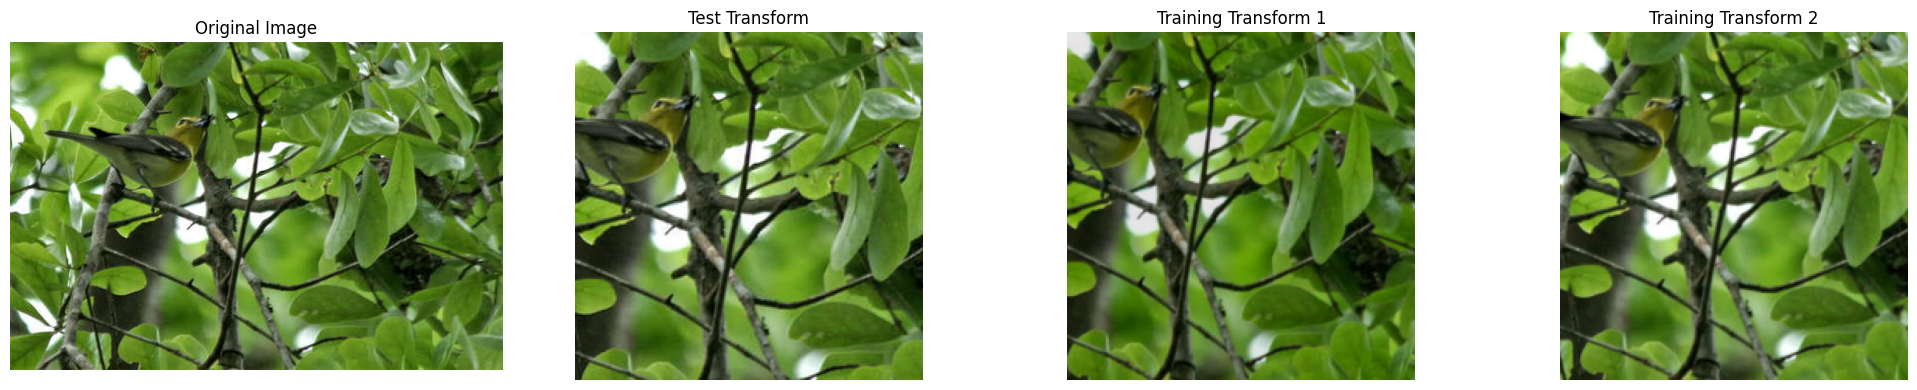


Image 2: Red_Headed_Woodpecker_0084_183004.jpg


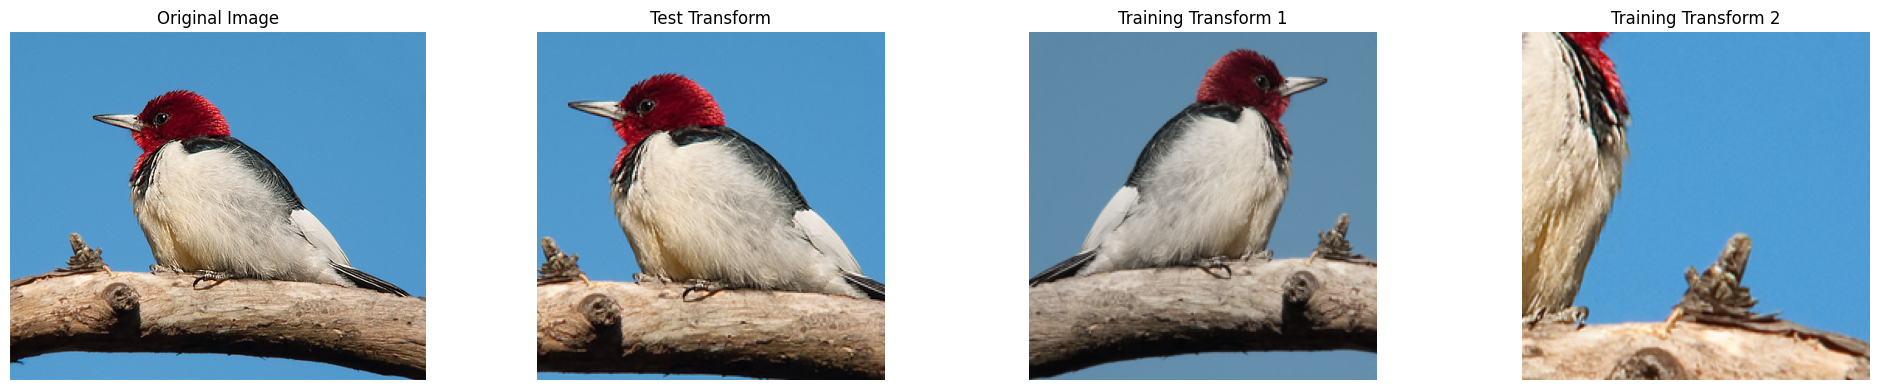

In [18]:
def visualize_multiple_images(image_dir, num_images=3, resolution=224):
    """
    Visualize multiple random images with their test and training transforms

    Args:
        image_dir (str): Directory containing images
        num_images (int): Number of different images to visualize
        resolution (int): Resolution for transforms
    """
    # Get all image paths
    all_image_paths = _get_all_filenames(image_dir)

    if len(all_image_paths) < num_images:
        num_images = len(all_image_paths)
        print(f"Only {num_images} images available")

    # Select random images
    sample_paths = random.sample(all_image_paths, num_images)

    # Create transform pipelines
    test_transform = _get_transform_pipeline(use_training_transforms=False, resol=resolution)
    train_transform = _get_transform_pipeline(use_training_transforms=True, resol=resolution)

    # Process each image
    for idx, path in enumerate(sample_paths):
        print(f"\nImage {idx+1}: {os.path.basename(path)}")

        # Load image
        original_img = Image.open(path).convert('RGB')

        # Apply test transform
        test_img_tensor = test_transform(original_img)

        # Apply training transform twice to show variability
        train_img_tensors = [train_transform(original_img), train_transform(original_img)]

        # Show comparison
        show_image_comparison(original_img, test_img_tensor, train_img_tensors, num_train_examples=2)

# Visualize transforms on multiple images
try:
    visualize_multiple_images(image_dir, num_images=2)
except Exception as e:
    print(f"An error occurred: {e}")